# Data Load

In [1]:
import numpy as np
from pathlib import Path


def load_dataset(path="/home/gmarihuan/processed/chbmit_windows_all.npz"):
    """Return the whole dataset as X (float32), y, patient."""
    d = np.load(path, allow_pickle=True)
    X = d["X"].astype(np.float32)
    y = d["y"]
    patient = d["patient_id"]
    return X, y, patient


X, y, patient = load_dataset()

# Model

In [2]:
"""
PyTorch implementation of

    Zhang et al., "Adversarial Representation Learning for Robust
    Patient-Independent Epileptic Seizure Detection",
    IEEE J. Biomedical and Health Informatics, 24(10), 2020.

Generalized to arbitrary window sizes. The paper uses (time=250, chan=22);
this version is configured for your data: (chan=21, time=768) = (21, 256*3).

--------------------------------------------------------------------------
INPUT CONVENTION
    Feed windows exactly as they come out of your loader:
        e : [B, n_chan, n_time]      e.g. [B, 21, 768]
    Internally this is transposed to [B, 1, n_time, n_chan] so that time is
    the conv "height" and channels the "width" (matching the paper, where the
    per-channel attention has one weight per channel).

WHY LAZY LAYERS
    The flatten dimension after the 4 conv/pool stages depends on the window
    size (1792 for the paper's 250x22, 6144 for your 768x21). Using
    nn.LazyLinear lets the first FC and the attention layer infer their input
    size automatically, so the model adapts to any window shape with no manual
    arithmetic. All lazy params are materialized in __init__ (a dummy forward),
    so you can build the optimizer immediately after construction.
--------------------------------------------------------------------------
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ----------------------------------------------------------------------
# 0. Shared layout helper
#    The decomposer works in [B,1,T,C] layout, but windows arrive as
#    [B,C,T]. This helper reshapes ground-truth E into the same layout as
#    the reconstruction so the loss can compare them directly, without the
#    model having to return its own input.
# ----------------------------------------------------------------------
def _to_nchw(e):
    """[B, C, T] -> [B, 1, T, C]; pass through if already 4-D."""
    return e.transpose(1, 2).unsqueeze(1) if e.dim() == 3 else e


# ----------------------------------------------------------------------
# 1. EEG decomposition (encoder + decoder), Eq. 2-5
# ----------------------------------------------------------------------
class Decomposer(nn.Module):
    """Encode E -> latent (S̄ or P̄), decode latent -> full component (S or P).

    Encoder : conv (SAME, stride 1) -> ReLU -> [2,1] max-pool over time
              [B,1,T,C] -> [B,4,T,C] -> [B,4,T//2,C]        (= S̄ / P̄)
    Decoder : transposed conv restores time T//2 -> T, 4 -> 1 filter
              [B,4,T//2,C] -> [B,1,T,C]                     (= S / P)
    The reconstruction is cropped/padded to match E exactly (handles odd T).
    """

    def __init__(self, n_filters: int = 4):
        super().__init__()
        self.enc = nn.Conv2d(1, n_filters, kernel_size=3, stride=1, padding="same")
        self.pool = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))
        self.dec = nn.ConvTranspose2d(n_filters, 1, kernel_size=(2, 1), stride=(2, 1))

    def forward(self, e):                     # e: [B,1,T,C]
        latent = F.relu(self.enc(e))          # [B,4,T,C]
        latent = self.pool(latent)            # [B,4,T//2,C]   S̄ / P̄
        recon = F.relu(self.dec(latent))      # [B,1,~T,C]     S / P
        recon = _match_time(recon, e.shape[2])  # force time dim == T
        return latent, recon


def _match_time(x, t_target):
    """Crop or zero-pad x along the time axis (dim 2) to length t_target."""
    t = x.shape[2]
    if t == t_target:
        return x
    if t > t_target:
        return x[:, :, :t_target, :]
    return F.pad(x, (0, 0, 0, t_target - t))   # pad time at the end


# ----------------------------------------------------------------------
# 2. Shared conv backbone: 4 conv+pool stages -> FC(300) -> FC(n_chan)
#    Used by both the seizure and patient branches (Fig. 1, Section IV-B).
# ----------------------------------------------------------------------
class ConvBackbone(nn.Module):
    """S̄/P̄ [B,4,T//2,C] -> feature vector of length `feat_dim` (= n_chan)."""

    def __init__(self, feat_dim: int, in_ch: int = 4, dropout: float = 0.2):
        super().__init__()
        # filters 16,32,64,128 ; kernels 3,3,2,2 ; all stride 1, SAME
        self.conv1 = nn.Conv2d(in_ch, 16, kernel_size=3, stride=1, padding="same")
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding="same")
        self.conv3 = nn.Conv2d(32, 64, kernel_size=2, stride=1, padding="same")
        self.conv4 = nn.Conv2d(64, 128, kernel_size=2, stride=1, padding="same")

        self.pool_22 = nn.MaxPool2d(kernel_size=2, stride=2)             # stages 1-3
        self.pool_21 = nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))   # stage 4

        self.flatten = nn.Flatten()
        self.drop = nn.Dropout(dropout)          # paper: 0.8 keep -> 0.2 drop
        self.fc1 = nn.LazyLinear(300)            # in-features inferred at runtime
        self.fc2 = nn.Linear(300, feat_dim)      # -> F²  (length = n_chan)

    def forward(self, x):                        # x: [B,4,T//2,C]
        x = self.pool_22(F.relu(self.conv1(x)))
        x = self.pool_22(F.relu(self.conv2(x)))
        x = self.pool_22(F.relu(self.conv3(x)))
        x = self.pool_21(F.relu(self.conv4(x)))
        x = self.drop(self.flatten(x))
        x = F.relu(self.fc1(x))          # was sigmoid — avoids saturation
        x = self.fc2(x)                  # was sigmoid — F² now signed (can be < 0)
        return x                         # [B, n_chan]  F²


# ----------------------------------------------------------------------
# 3. Attention-weighted seizure head, Eq. 11-12
# ----------------------------------------------------------------------
class SeizureHead(nn.Module):
    def __init__(self, n_chan: int):
        super().__init__()
        self.att = nn.LazyLinear(n_chan)
        self.classifier = nn.Linear(n_chan, 1)   # signed weights + bias

    def forward(self, f2, e_flat):
        att = torch.sigmoid(self.att(e_flat))    # [B,C] positive importance
        logit = self.classifier(f2 * att)        # [B,1] can be any sign
        return logit, att


# ----------------------------------------------------------------------
# 4. Full model
# ----------------------------------------------------------------------
class AdversarialSeizureNet(nn.Module):
    def __init__(self, n_patients: int, n_chan: int = 21, n_time: int = 768,
                 dropout: float = 0.2, w1: float = 0.5):
        super().__init__()
        self.n_chan, self.n_time = n_chan, n_time
        self.w1, self.w2 = w1, 1.0 - w1          # Eq. 6 reconstruction weights

        self.seizure_decomp = Decomposer()       # E -> S̄, S
        self.patient_decomp = Decomposer()       # E -> P̄, P

        self.seizure_backbone = ConvBackbone(feat_dim=n_chan, dropout=dropout)
        self.patient_backbone = ConvBackbone(feat_dim=n_chan, dropout=dropout)

        self.seizure_head = SeizureHead(n_chan)
        self.patient_head = nn.Linear(n_chan, n_patients)   # -> C classes

        self._materialize()                      # init all LazyLinear params

    def _materialize(self):
        """Run one dummy forward so lazy layers create their weights,
        letting you build the optimizer right after construction."""
        was_training = self.training
        self.eval()
        with torch.no_grad():
            self(torch.zeros(1, self.n_chan, self.n_time))
        self.train(was_training)

    def forward(self, e):                        # e: [B, n_chan, n_time]
        e = _to_nchw(e)                          # -> [B,1,n_time,n_chan]
        e_flat = e.flatten(1)                    # [B, n_time*n_chan]

        s_lat, s_rec = self.seizure_decomp(e)    # S̄, S
        p_lat, p_rec = self.patient_decomp(e)    # P̄, P
        e_recon = self.w1 * s_rec + self.w2 * p_rec           # Ê  (Eq. 6)

        f2_s = self.seizure_backbone(s_lat)
        seizure_logit, att = self.seizure_head(f2_s, e_flat)  # [B,1], [B,C]

        f2_p = self.patient_backbone(p_lat)
        patient_logits = self.patient_head(f2_p)              # [B,C_patients]

        return {
            "seizure_logit": seizure_logit,      # [B,1]  BCE-with-logits target
            "patient_logits": patient_logits,    # [B,C]  CE target
            "e_recon": e_recon,                  # [B,1,n_time,n_chan]  (Ê only)
            "attention": att,                    # [B,n_chan]
            "S": s_rec, "P": p_rec,
            "S_latent": s_lat, "P_latent": p_lat,
        }


# ----------------------------------------------------------------------
# 5. Losses and the two-pass training step (Section III-E, Algorithm 1)
# ----------------------------------------------------------------------
def compute_losses(out, e, y_seizure, y_patient):
    # Ground truth E is reshaped here (not returned by the model) so the loss
    # owns the data<->reconstruction comparison. Gradients flow only through
    # e_recon; e_target is data with requires_grad=False.
    e_target = _to_nchw(e)                                          # match e_recon layout
    l_d = F.mse_loss(out["e_recon"], e_target)                     # L_D  (Eq. 7)
    l_s = F.binary_cross_entropy_with_logits(                      # L_s  (Eq. 13)
        out["seizure_logit"], y_seizure.float().view(-1, 1))
    l_p = F.cross_entropy(out["patient_logits"], y_patient.long()) # L_p  (Eq. 14)
    return l_d, l_s, l_p


def train_step(model, optimizer, e, y_seizure, y_patient):
    """Pass 1 minimizes L = L_D + L_s + L_p; pass 2 minimizes L_s again to
    raise the seizure task's priority (as the paper does)."""
    model.train()

    optimizer.zero_grad()
    out = model(e)
    # L_D: Signal Reconstruction (decomposition) Loss
    # L_S: Seizure Loss
    # L_P: Patient Loss
    l_d, l_s, l_p = compute_losses(out, e, y_seizure, y_patient)
    (l_d + l_s + l_p).backward()
    optimizer.step()

    optimizer.zero_grad()
    out = model(e)
    _, l_s2, _ = compute_losses(out, e, y_seizure, y_patient)
    l_s2.backward()
    optimizer.step()

    return {"L_D": l_d.item(), "L_s": l_s.item(),
            "L_p": l_p.item(), "L_s_repeat": l_s2.item()}


def make_optimizer(model, lr: float = 1e-4, weight_decay: float = 1e-4):
    # lr = 1e-4 (Adam); L2 coefficient 0.0001 -> weight_decay (Section III-E)
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


# ----------------------------------------------------------------------
# Smoke test on YOUR window shape: (21, 768)
# ----------------------------------------------------------------------
if __name__ == "__main__":
    torch.manual_seed(0)
    B, C = 8, 13                       # batch, #training patients
    N_CHAN, N_TIME = 21, 256 * 3       # your window shape

    model = AdversarialSeizureNet(n_patients=C, n_chan=N_CHAN, n_time=N_TIME)
    opt = make_optimizer(model)
    
    # The signal (window as (21, 768) )
    e = torch.randn(B, N_CHAN, N_TIME)          
    y_seiz = torch.randint(0, 2, (B,))
    y_pat = torch.randint(0, C, (B,))

    out = model(e)
    print("seizure_logit :", tuple(out["seizure_logit"].shape))   # (8, 1)
    print("patient_logits:", tuple(out["patient_logits"].shape))  # (8, 13)
    print("e_recon       :", tuple(out["e_recon"].shape))         # (8,1,768,21)
    print("attention     :", tuple(out["attention"].shape))       # (8, 21)

    logs = train_step(model, opt, e, y_seiz, y_pat)
    print("losses        :", {k: round(v, 4) for k, v in logs.items()})
    print("params        :", f"{sum(p.numel() for p in model.parameters()):,}")

/home/gmarihuan/.conda/envs/torchy/lib/python3.10/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


seizure_logit : (8, 1)
patient_logits: (8, 13)
e_recon       : (8, 1, 768, 21)
attention     : (8, 21)
losses        : {'L_D': 1.0857, 'L_s': 0.6991, 'L_p': 2.5445, 'L_s_repeat': 0.6946}
params        : 4,131,525


# Training

In [3]:
import numpy as np


def exclude_patients(X, y, patient, exclude):
    """Drop windows belonging to the given patient id(s).

    Parameters
    ----------
    X, y, patient : arrays from load_dataset()  (aligned along axis 0)
    exclude       : a single patient id or an iterable of ids to remove

    Returns
    -------
    X, y, patient : same format, with the excluded patients removed
    """
    exclude = set(np.atleast_1d(exclude).tolist())
    mask = ~np.isin(patient, list(exclude))
    return X[mask], y[mask], patient[mask]


In [4]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split



# ---------------------------------------------------------
# 1. UPDATED HELPER FUNCTIONS (Now tracking patient IDs)
# ---------------------------------------------------------
def get_split(X, y, patient, test_patients, val_size=0.2, random_state=42):
    X, y, patient = np.array(X), np.array(y), np.array(patient)
    
    test_mask = np.isin(patient, test_patients)
    X_test, y_test, p_test = X[test_mask], y[test_mask], patient[test_mask]
    
    train_val_mask = ~test_mask
    X_train_val, y_train_val, p_train_val = X[train_val_mask], y[train_val_mask], patient[train_val_mask]
    
    # Remap training patient IDs to contiguous 0..C-1 for the Adversarial Network
    uniq = np.unique(p_train_val)
    remap = {p: i for i, p in enumerate(uniq)}
    p_train_val_remapped = np.array([remap[p] for p in p_train_val])
    C = len(uniq) # Total number of training patients
    
    X_train, X_val, y_train, y_val, p_train, p_val = train_test_split(
        X_train_val, y_train_val, p_train_val_remapped, 
        test_size=val_size, random_state=random_state, stratify=y_train_val
    )
    
    return (X_train, y_train, p_train), (X_val, y_val, p_val), (X_test, y_test, p_test), C

def create_dataloaders(X_train, y_train, p_train, X_val, y_val, p_val, X_test, y_test, p_test, batch_size=64):
    # Train Dataset (includes patient IDs)
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32), 
        torch.tensor(y_train, dtype=torch.float32),
        torch.tensor(p_train, dtype=torch.long)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Validation Dataset (includes patient IDs)
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32), 
        torch.tensor(y_val, dtype=torch.float32),
        torch.tensor(p_val, dtype=torch.long)
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Test Dataset (Patient IDs not strictly needed for test evaluation, but kept for consistency)
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32), 
        torch.tensor(y_test, dtype=torch.float32)
    )
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

Epoch [1/250] | Train L_s: 0.6318 | Train L_p: 3.0069 | Val L_s: 0.5863
Epoch [2/250] | Train L_s: 0.5356 | Train L_p: 2.7462 | Val L_s: 0.5571
Epoch [3/250] | Train L_s: 0.4630 | Train L_p: 2.4188 | Val L_s: 0.4635
Epoch [4/250] | Train L_s: 0.3959 | Train L_p: 2.0451 | Val L_s: 0.4260
Epoch [5/250] | Train L_s: 0.3441 | Train L_p: 1.7731 | Val L_s: 0.4582
Epoch [6/250] | Train L_s: 0.3317 | Train L_p: 1.6824 | Val L_s: 0.4261
Epoch [7/250] | Train L_s: 0.2853 | Train L_p: 1.4864 | Val L_s: 0.4203
Epoch [8/250] | Train L_s: 0.2646 | Train L_p: 1.3627 | Val L_s: 0.4584
Epoch [9/250] | Train L_s: 0.2501 | Train L_p: 1.2939 | Val L_s: 0.5408
Epoch [10/250] | Train L_s: 0.2224 | Train L_p: 1.1615 | Val L_s: 0.4880
Epoch [11/250] | Train L_s: 0.1905 | Train L_p: 1.1296 | Val L_s: 0.5183
Epoch [12/250] | Train L_s: 0.1703 | Train L_p: 1.0520 | Val L_s: 0.5512
Epoch [13/250] | Train L_s: 0.1580 | Train L_p: 0.9675 | Val L_s: 0.5220
Epoch [14/250] | Train L_s: 0.1490 | Train L_p: 0.8949 | Val

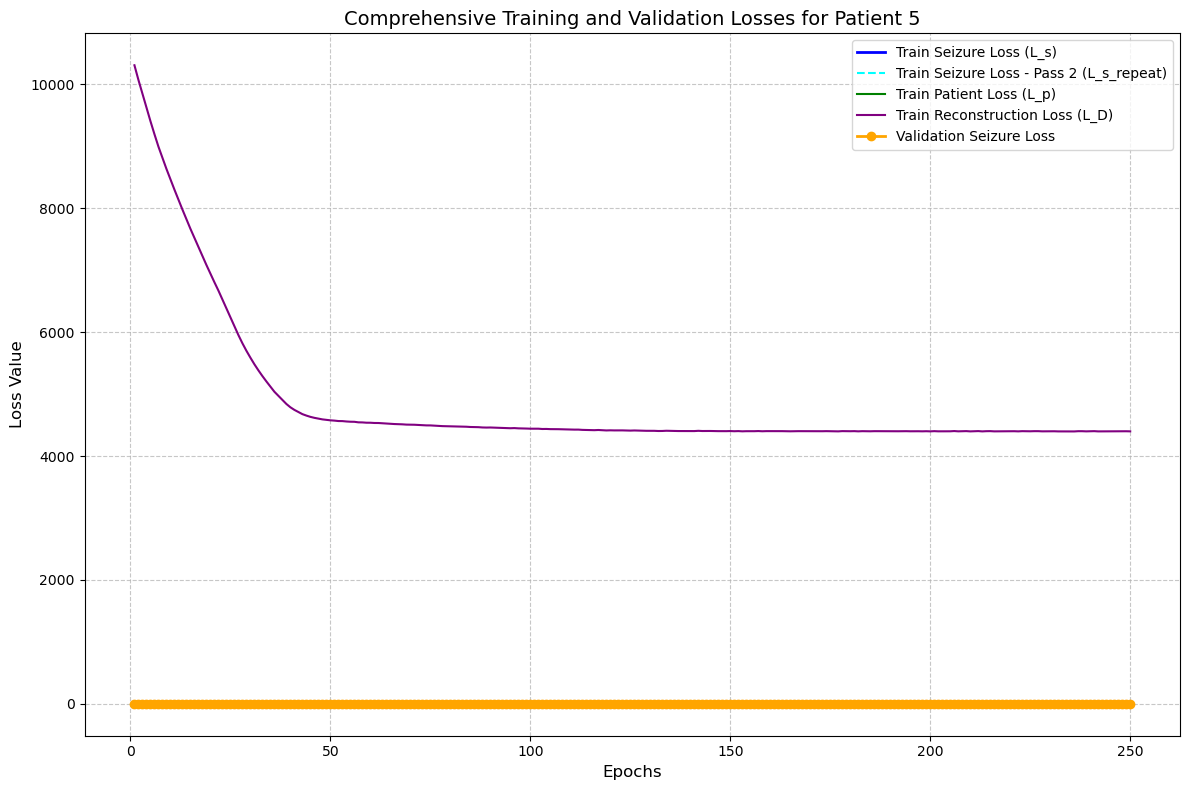

In [5]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
torch.manual_seed(0)
EPOCHS, B = 250, 64
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Select the specific patient ID you want to hold out for testing
test_pat = 5  

# 1. Split Data
(X_train, y_train, p_train), (X_val, y_val, p_val), (X_test, y_test, p_test), num_train_patients = get_split(
    X, y, patient, test_patients=[test_pat], val_size=0.2
)

# 2. Create DataLoaders
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, y_train, p_train, 
    X_val, y_val, p_val, 
    X_test, y_test, p_test, 
    batch_size=B
)

# 3. Initialize Model and Optimizer
model = AdversarialSeizureNet(n_patients=num_train_patients, n_chan=21, n_time=768).to(dev)
opt = make_optimizer(model)

# Lists to track all losses for plotting
train_losses_s = []
train_losses_p = []
train_losses_d = []
train_losses_s_repeat = []
val_losses = []

# 4. Training Loop with Validation
for ep in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_train_s = 0.0
    running_train_p = 0.0
    running_train_d = 0.0
    running_train_s_repeat = 0.0
    
    for batch_X, batch_y, batch_p in train_loader:
        batch_X, batch_y, batch_p = batch_X.to(dev), batch_y.to(dev), batch_p.to(dev)
        
        # train_step returns a dictionary of all losses
        loss_dict = train_step(model, opt, batch_X, batch_y, batch_p)
        
        # Accumulate each loss type
        running_train_s += loss_dict["L_s"]
        running_train_p += loss_dict["L_p"]
        running_train_d += loss_dict["L_D"]
        running_train_s_repeat += loss_dict["L_s_repeat"]
        
    # Calculate epoch averages
    num_batches = len(train_loader)
    train_losses_s.append(running_train_s / num_batches)
    train_losses_p.append(running_train_p / num_batches)
    train_losses_d.append(running_train_d / num_batches)
    train_losses_s_repeat.append(running_train_s_repeat / num_batches)
    
    # --- Validation Phase ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y, batch_p in val_loader:
            batch_X, batch_y, batch_p = batch_X.to(dev), batch_y.to(dev), batch_p.to(dev)
            
            outputs = model(batch_X)
            logit = outputs["seizure_logit"].squeeze()
            
            # Compute classification loss using Binary Cross Entropy
            val_loss = F.binary_cross_entropy_with_logits(logit, batch_y.float())
            running_val_loss += val_loss.item()
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Print progress
    print(f"Epoch [{ep+1}/{EPOCHS}] | Train L_s: {train_losses_s[-1]:.4f} | Train L_p: {train_losses_p[-1]:.4f} | Val L_s: {avg_val_loss:.4f}")

# 5. Plot the Losses
plt.figure(figsize=(12, 8))

# Define the x-axis
epochs_range = range(1, EPOCHS + 1)

# Plot Training Losses
plt.plot(epochs_range, train_losses_s, label='Train Seizure Loss (L_s)', color='blue', linewidth=2)
plt.plot(epochs_range, train_losses_s_repeat, label='Train Seizure Loss - Pass 2 (L_s_repeat)', color='cyan', linestyle='--')
plt.plot(epochs_range, train_losses_p, label='Train Patient Loss (L_p)', color='green')
plt.plot(epochs_range, train_losses_d, label='Train Reconstruction Loss (L_D)', color='purple')

# Plot Validation Loss
plt.plot(epochs_range, val_losses, label='Validation Seizure Loss', color='orange', marker='o', linewidth=2)

# Formatting the plot
plt.title(f'Comprehensive Training and Validation Losses for Patient {test_pat}', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Evaluation

In [6]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def evaluate_model(model, test_loader, device=None):
    """
    Evaluates the AdversarialSeizureNet model on the test dataset.
    Calculates Accuracy, Binary F1-Score, Weighted F1-Score, Sensitivity, and Specificity.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            # Unpack dynamically in case the loader yields patient IDs as a third item
            if len(batch) == 3:
                inputs, targets, _ = batch
            else:
                inputs, targets = batch
                
            inputs, targets = inputs.to(device), targets.to(device)
            
            # REMOVED: The unsqueeze logic. We now pass the raw 3D tensor 
            # exactly as AdversarialSeizureNet expects it.
            outputs = model(inputs)
            
            # Extract logits and apply Sigmoid thresholding
            logit = outputs["seizure_logit"].squeeze()
            prob = torch.sigmoid(logit)
            preds = (prob > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 1. Accuracy
    accuracy = accuracy_score(all_targets, all_preds)
    
    # 2. F1 Scores 
    f1_bin = f1_score(all_targets, all_preds, average='binary', zero_division=0)
    f1_weight = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    
    # 3. Sensitivity and Specificity via Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        sensitivity = 0.0
        specificity = 0.0
        print("Warning: Confusion matrix is not 2x2. Test set may be missing a class.")

    # Print nicely formatted results
    print("--- Test Set Evaluation ---")
    print(f"Accuracy:          {accuracy * 100:.2f}%")
    print(f"F1-Score (Binary): {f1_bin * 100:.2f}%")
    print(f"F1-Score (Weight): {f1_weight * 100:.2f}%")
    print(f"Sensitivity:       {sensitivity * 100:.2f}%")
    print(f"Specificity:       {specificity * 100:.2f}%")
    print("---------------------------")
    
    return {
        'accuracy': accuracy,
        'f1_binary': f1_bin,
        'f1_weighted': f1_weight,
        'sensitivity': sensitivity,
        'specificity': specificity
    }

In [7]:
# 5. Evaluate Model
metrics = evaluate_model(model, test_loader, device=dev)

# 6. Display Results
acc = metrics['accuracy']
sens = metrics['sensitivity']
spec = metrics['specificity']
n_samples = len(y_test)

print("-" * 50)
print(f"Results for held-out patient {test_pat}:")
print(f"Accuracy:    {acc:.3f}")
print(f"Sensitivity: {sens:.3f}")
print(f"Specificity: {spec:.3f}")
print(f"Samples (n): {n_samples}")
print("-" * 50)

--- Test Set Evaluation ---
Accuracy:          66.67%
F1-Score (Binary): 69.81%
F1-Score (Weight): 66.30%
Sensitivity:       77.08%
Specificity:       56.25%
---------------------------
--------------------------------------------------
Results for held-out patient 5:
Accuracy:    0.667
Sensitivity: 0.771
Specificity: 0.562
Samples (n): 96
--------------------------------------------------


# Run n times

In [10]:
import numpy as np
import torch

def run_n_experiments(X, y, patient, test_patients=[0], n_runs=5, batch_size=512, timepoints=768, epochs=50):
    """
    Runs the data splitting, dataloader creation, model training, and evaluation pipeline N times.
    Calculates and reports mean and standard deviation for all evaluation metrics.
    """
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Dictionary to aggregate metrics across all N runs
    all_metrics = {
        'accuracy': [],
        'f1_binary': [],
        'f1_weighted': [],
        'sensitivity': [],
        'specificity': []
    }

    for run in range(n_runs):
        print(f"\n==================================================")
        print(f"                 RUN {run + 1} / {n_runs}                 ")
        print(f"==================================================")
        
        # Set distinct seeds for each run to vary train/val split and model weight initialization
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)

        # 1. Split Data 
        # (Now expecting patient outputs and total training patients count)
        (X_train, y_train, p_train), (X_val, y_val, p_val), (X_test, y_test, p_test), num_train_patients = get_split(
            X, y, patient, test_patients=test_patients, val_size=0.2, random_state=seed
        )

        # 2. Create DataLoaders 
        # (Now passing the patient arrays)
        train_loader, val_loader, test_loader = create_dataloaders(
            X_train, y_train, p_train, 
            X_val, y_val, p_val, 
            X_test, y_test, p_test,      
            batch_size=batch_size
        )

        # 3. Instantiate Fresh Model and Optimizer
        model = AdversarialSeizureNet(n_patients=num_train_patients, n_chan=21, n_time=timepoints).to(dev)
        opt = make_optimizer(model)

        # 4. Train Model
        # (Replaced train_model with the adversarial train_step loop)
        model.train()
        for ep in range(epochs):
            for batch_X, batch_y, batch_p in train_loader:
                batch_X, batch_y, batch_p = batch_X.to(dev), batch_y.to(dev), batch_p.to(dev)
                
                # Using the custom adversarial train_step function
                train_step(model, opt, batch_X, batch_y, batch_p)

        # 5. Evaluate Model on Test Set
        run_metrics = evaluate_model(model, test_loader, device=dev)

        # 6. Record Results
        for metric_name in all_metrics:
            all_metrics[metric_name].append(run_metrics[metric_name])

    # Summary Report
    print("\n" + "=" * 50)
    print(f"    FINAL AGGREGATED METRICS ACROSS {n_runs} RUNS    ")
    print("=" * 50)
    
    summary_metrics = {}
    for metric_name, values in all_metrics.items():
        mean_val = np.mean(values) * 100
        std_val = np.std(values) * 100
        summary_metrics[f"{metric_name}_mean"] = mean_val
        summary_metrics[f"{metric_name}_std"] = std_val
        
        formatted_name = metric_name.replace('_', ' ').title()
        print(f"{formatted_name:<20}: {mean_val:.2f}% ± {std_val:.2f}%")
        
    print("=" * 50)

    return summary_metrics, all_metrics

# --- Example Usage ---
summary, raw_history = run_n_experiments(
      X, y, patient, 
      test_patients=[5], 
      n_runs=10, 
      batch_size=512, 
      timepoints=768
  )


                 RUN 1 / 10                 
--- Test Set Evaluation ---
Accuracy:          65.62%
F1-Score (Binary): 67.33%
F1-Score (Weight): 65.53%
Sensitivity:       70.83%
Specificity:       60.42%
---------------------------

                 RUN 2 / 10                 
--- Test Set Evaluation ---
Accuracy:          60.42%
F1-Score (Binary): 66.07%
F1-Score (Weight): 59.29%
Sensitivity:       77.08%
Specificity:       43.75%
---------------------------

                 RUN 3 / 10                 
--- Test Set Evaluation ---
Accuracy:          58.33%
F1-Score (Binary): 60.00%
F1-Score (Weight): 58.26%
Sensitivity:       62.50%
Specificity:       54.17%
---------------------------

                 RUN 4 / 10                 
--- Test Set Evaluation ---
Accuracy:          52.08%
F1-Score (Binary): 53.06%
F1-Score (Weight): 52.06%
Sensitivity:       54.17%
Specificity:       50.00%
---------------------------

                 RUN 5 / 10                 
--- Test Set Evaluation --